In [1]:
from matrix import*  
from setra import* 
from pedestrian import* 
from matplotlib import pyplot as plt
import timeit
import numpy as np


#step 1 setup beam and pedestrians
#beam
numElements = 10  # n - Number of beam elements !not for modal
length = 50  # L - Length (m)
width = 2  # b - Width (m)
height = 0.6  # h - Height (m)
E = 200e9  # E - Young's modulus (N/m^2)
modalDampingRatio = 0.005  # xi - Modal damping ratio of the beam
nHigh = 3  # nHigh - Higher mode for damping matrix
beamFreq =2 #Hz
area = 0.3162  # A - Cross-section area (m^2)
linearMass = 500  # m - Linear mass (kg/m)
x_interested= length/2
numbers = 1
#ped
numped = 1
pedmass = 80     #kg
peddamp = .3    
#pedstiff = 25000 #N/m
pedpace  = 2     #Hz
pedphase = 0
pedInlocation = 0
pedvelocity = 1.25
pedBodyF= 2 #Hz
d=0
#ped
kped=(2*np.pi*pedBodyF)**2*pedmass
cped = (2*np.pi*pedBodyF)*2*peddamp*pedmass

#mat=np.zeros(1,numped) #to be extended into probabilistic inputs
mped=np.array([pedmass])
cped = np.array([cped])
kped = np.array([kped])

#bridge
modulus =linearMass * ((2 * math.pi * beamFreq) * (math.pi / length) ** (-2)) ** 2  #E*(width*height**3)/12

#set time info
hht=0.01

#initial possition vector.......formultiple ped all these would become matrices

#xrb=np.zeros(1,numped)
xrb=[0]

Bridge = bridge(   
    length = length,                 # m
    modulus = modulus,               # N m^2
    density = linearMass,            # kg/m
    damp    = modalDampingRatio ,    #%
    numbers = 1,  )                   #modes
    

Human = Pedestrian(
         mass = pedmass,     #kg
         damp = peddamp ,   #%
         stiff = kped, #N/m
         pace  = pedpace ,    #Hz
         phase = pedphase,
         location = pedInlocation,
         velocity = pedvelocity,
         
         iSync=0)


t = np.arange(0, (length+1) / pedvelocity, hht)

In [2]:
u,du,ddu = Newmarksuper_singlesetra (Human,Bridge,numped,numbers,length, hht, pedvelocity,xrb,linearMass,beamFreq)
                
accn= accdyn_super(Bridge,ddu,x_interested,hht)



[[ 0.00000000e+00  1.95798786e-03  3.85186815e-03 ... -1.66632085e+01
  -1.06838971e+00  0.00000000e+00]]


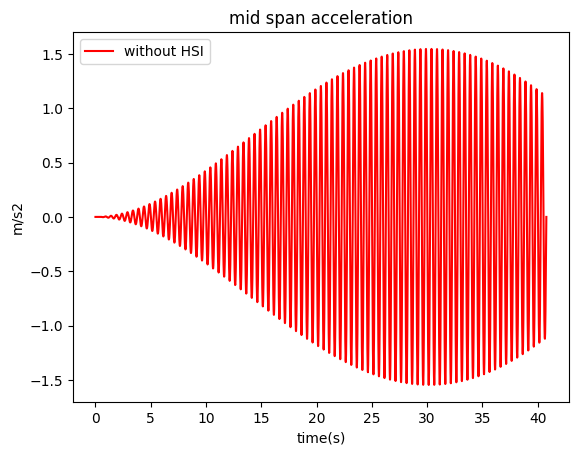

Maximum acceleration: 1.545701612105166 m/s² at time 30.400000000000002 s


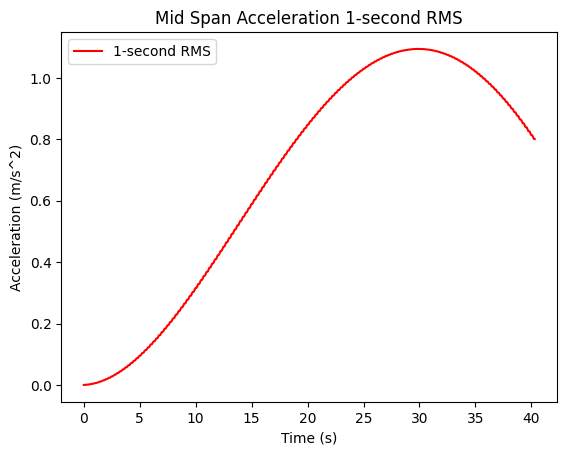

Maximum acceleration: 1.093944254030352 m/s² at time 30.03 s


: 

In [4]:
t = np.arange(0, (length+1) / pedvelocity, hht)
plt.plot(t,accn, label ="without HSI" ,color='r')
#plt.plot(t,accn_HSI,label ="with HSI",color='b')
plt.title("mid span acceleration")
plt.xlabel("time(s)")
plt.ylabel("m/s2")
plt.legend()  
plt.show()


# Find the index of the maximum value in accn
max_index_accn = np.argmax(accn)

# Find the maximum value
max_accn = accn[max_index_accn]

# Find the corresponding time
max_time_accn = t[max_index_accn]

# Print the results
print(f"Maximum acceleration: {max_accn} m/s² at time {max_time_accn} s")

# Define the sampling rate (samples per second)
sampling_rate = 0.5 / (t[1] - t[0])  # Assuming t is uniformly spaced

# Define the window size for 1 second
window_size = int(sampling_rate)

# Calculate the 1-second RMS values
rms_1s = np.array([np.sqrt(np.mean(accn[i:i + window_size]**2)) for i in range(0, len(accn) - window_size + 1)])

# Create a time array for the RMS values
rms_time = t[:len(rms_1s)]




plt.plot(rms_time, rms_1s, label="1-second RMS", color='r')
plt.title("Mid Span Acceleration 1-second RMS")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (m/s^2)")
plt.legend()
plt.show()

max_index_accn = np.argmax(rms_1s)

# Find the maximum value
max_accn = rms_1s[max_index_accn]

# Find the corresponding time
max_time_accn = t[max_index_accn]
# Print the results
print(f"Maximum acceleration: {max_accn} m/s² at time {max_time_accn} s")